In [30]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

# Librerías de Machine Learning
from sklearn.linear_model import SGDRegressor
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score 

# Configuración visual
sns.set_style("whitegrid")
pd.set_option('display.max_columns', None)
print("Librerías cargadas.")

Librerías cargadas.


In [31]:
# --- CONFIGURACIÓN DE RUTA ---

db_path = 'nba_stats.db'
conn = sqlite3.connect(db_path)

# Query optimizada: Traemos todo, filtramos después en Pandas para tener control
query = """
SELECT
    info.player,
    s.season,
    s.team,
    s.age,
    s.pos,
    info.ht_in_in AS altura,
    pg.g AS partidos,
    pg.mp_per_game AS minutos,
    pg.pts_per_game AS puntos,
    pg.trb_per_game AS rebotes,
    pg.ast_per_game AS asistencias,
    pg.stl_per_game AS robos,
    pg.blk_per_game AS bloqueos,
    pg.tov_per_game AS perdidas,
    pg.x3p_per_game AS triples_anotados,
    pg.fga_per_game AS intentos_tiro,
    adv.per AS eficiencia,
    adv.usg_percent AS uso,
    adv.ts_percent AS tiro_verdadero,
    adv.bpm AS box_plus_minus
FROM Player_Career_Info info
JOIN Player_Per_Game pg ON info.player_id = pg.player_id
JOIN Advanced adv ON info.player_id = adv.player_id AND pg.season = adv.season
JOIN Player_Season_Info s ON info.player_id = s.player_id AND pg.season = s.season
WHERE s.season >= 2018
"""

df = pd.read_sql_query(query, conn)
conn.close()


In [32]:
# Conversión numérica 
cols_numericas = ['age', 'altura', 'partidos', 'minutos', 'puntos',
                  'rebotes', 'asistencias', 'robos', 'bloqueos',
                  'perdidas', 'triples_anotados', 'intentos_tiro',
                  'eficiencia', 'uso', 'tiro_verdadero', 'box_plus_minus']

for col in cols_numericas:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df = df.fillna(0)
print(f"Dataset crudo cargado: {df.shape[0]} registros.")

Dataset crudo cargado: 22425 registros.


In [33]:
# 1. Limpieza de Texto
for col in ['player', 'team', 'pos']:
    df[col] = df[col].astype(str).str.strip()

In [34]:
# 2. Filtro Lógico de Calidad
# Bajamos la vara a 3 partidos/5 mins para no matar a los rookies ni a equipos con poca data
df_clean = df[ (df['partidos'] >= 3) & (df['minutos'] >= 5.0) ].copy()

In [35]:
# 3. Manejo de Duplicados (Jugadores que cambiaron de equipo)
# Nos quedamos con la fila donde jugaron más partidos esa temporada (TOT o equipo principal)
df_clean = df_clean.sort_values('partidos', ascending=False).drop_duplicates(subset=['player', 'season'], keep='first')

In [36]:
# 4. One-Hot Encoding (Equipo y Posición)
# Hacemos esto ANTES de separar train/test para que las columnas sean idénticas
df_processed = pd.get_dummies(df_clean, columns=['team', 'pos'], prefix=['team', 'pos'], dtype=int)

print(f"Datos procesados. Dimensiones: {df_processed.shape}")
print(f"Equipos detectados: {[c for c in df_processed.columns if 'team_' in c]}")

Datos procesados. Dimensiones: (4386, 56)
Equipos detectados: ['team_2TM', 'team_3TM', 'team_4TM', 'team_ATL', 'team_BOS', 'team_BRK', 'team_CHI', 'team_CHO', 'team_CLE', 'team_DAL', 'team_DEN', 'team_DET', 'team_GSW', 'team_HOU', 'team_IND', 'team_LAC', 'team_LAL', 'team_MEM', 'team_MIA', 'team_MIL', 'team_MIN', 'team_NOP', 'team_NYK', 'team_OKC', 'team_ORL', 'team_PHI', 'team_PHO', 'team_POR', 'team_SAC', 'team_SAS', 'team_TOR', 'team_UTA', 'team_WAS']


In [37]:
# 7. GUARDAR CSV FINAL EN TU DRIVE 💾
# Usamos la misma ruta base donde tienes tu base de datos
ruta_guardado = 'nba_datos_limpios.csv'

try:
    df.to_csv(ruta_guardado, index=False)
    print(f"✅ Celda 3 Completada.")
    print(f"📊 Filas finales: {df.shape[0]}")
    print(f"💾 EXCELENTE: Archivo guardado exitosamente en: {ruta_guardado}")
except Exception as e:
    print(f"❌ Error al guardar en Drive: {e}")
    print("Asegúrate de que la carpeta 'NBA_stats' existe en tu Drive.")

✅ Celda 3 Completada.
📊 Filas finales: 22425
💾 EXCELENTE: Archivo guardado exitosamente en: nba_datos_limpios.csv


In [38]:
# 1. Definir Target (Lo que queremos predecir)
target = 'puntos'

# 2. Definir Features (Con qué predecimos)
# EXCLUIMOS: Puntos (obvio), Rebotes/Asistencias (son otros resultados), Intentos de Tiro (Data Leakage grave)
drop_cols = ['player', 'season', 'puntos', 'rebotes', 'asistencias', 'robos',
             'bloqueos', 'perdidas', 'triples_anotados', 'intentos_tiro']

In [40]:
# X será todo MENOS las columnas de arriba
X = df_processed.drop(columns=drop_cols, errors='ignore')
y = df_processed[target]

# 3. SPLIT TEMPORAL (Correcto para deportes)
# Entrenamos con historia (ej. 2018-2024)
# Probamos/Predecimos con lo actual (ej. 2025 o 2026)
latest_season = df_processed['season'].max()

X_train = X[df_processed['season'] < latest_season]
y_train = y[df_processed['season'] < latest_season]

X_test = X[df_processed['season'] == latest_season]
y_test = y[df_processed['season'] == latest_season]

# 4. Escalado (Solo fit en Train para no contaminar)
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"✅ Split Temporal Realizado:")
print(f"   -> Train (Historia): {X_train.shape[0]} filas (Temps < {latest_season})")
print(f"   -> Test (Actualidad): {X_test.shape[0]} filas (Temp {latest_season})")
print(f"Total de datos: {X_train.shape[0] + X_test.shape[0]}")

✅ Split Temporal Realizado:
   -> Train (Historia): 4051 filas (Temps < 2026)
   -> Test (Actualidad): 335 filas (Temp 2026)
Total de datos: 4386


In [43]:
# 3. Entrenamiento con Historial
model = SGDRegressor(loss='huber', max_iter=1, tol=None, penalty='l2', alpha=0.001, learning_rate='adaptive', eta0=0.01, random_state=42, warm_start=True)
train_loss, val_loss = [], []

print(" Celda 4: Entrenando modelo (50 épocas)...")
for _ in range(50):
    model.fit(X_train_scaled, y_train)
    train_loss.append(mean_absolute_error(y_train, model.predict(X_train_scaled)))
    val_loss.append(mean_absolute_error(y_test, model.predict(X_test_scaled)))

 Celda 4: Entrenando modelo (50 épocas)...


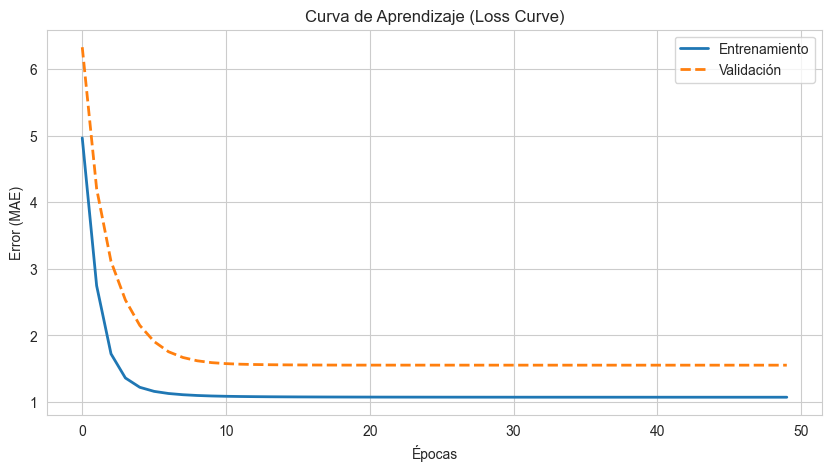

In [45]:
# 4. Gráfica de Pérdida
plt.figure(figsize=(10, 5))
plt.plot(train_loss, label='Entrenamiento', linewidth=2)
plt.plot(val_loss, label='Validación', linewidth=2, linestyle='--')
plt.title("Curva de Aprendizaje (Loss Curve)")
plt.xlabel("Épocas"); plt.ylabel("Error (MAE)")
plt.legend(); plt.grid(True); plt.show()

In [46]:


# 1. Hacer predicciones finales en el set de prueba
y_pred = model.predict(X_test_scaled)

# 2. Calcular todas las métricas
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

# 3. Reporte Profesional
print("\n" + "="*40)
print("📊 REPORTE FINAL DE RENDIMIENTO")
print("="*40)
print(f"🎯 MAE (Error Absoluto Medio):  +/- {mae:.2f} Puntos")
print(f"   -> Interpretación: El modelo suele fallar por {mae:.1f} puntos arriba o abajo.")
print("-" * 40)
print(f"📉 RMSE (Raíz Error Cuadrático):    {rmse:.2f} Puntos")
print(f"   -> Interpretación: Penaliza más los fallos grandes (outliers).")
print("-" * 40)
print(f"📈 R2 Score (Precisión Global):     {r2:.4f} (Máx 1.0)")
print(f"   -> Interpretación: El modelo explica el {r2*100:.1f}% del comportamiento del jugador.")
print("="*40)


📊 REPORTE FINAL DE RENDIMIENTO
🎯 MAE (Error Absoluto Medio):  +/- 1.55 Puntos
   -> Interpretación: El modelo suele fallar por 1.6 puntos arriba o abajo.
----------------------------------------
📉 RMSE (Raíz Error Cuadrático):    2.37 Puntos
   -> Interpretación: Penaliza más los fallos grandes (outliers).
----------------------------------------
📈 R2 Score (Precisión Global):     0.9051 (Máx 1.0)
   -> Interpretación: El modelo explica el 90.5% del comportamiento del jugador.


In [48]:
# Recuperamos la info humana (Nombre, Equipo) del set de Test
df_final = df_clean[df_clean['season'] == latest_season].copy()

# Agregamos las predicciones
df_final['pred_puntos'] = np.round(y_pred, 1)
df_final['real_puntos'] = df_final['puntos']

# Proyecciones simples (Piso/Techo basados en la predicción base +/- 20%)
# Nota: Esto es una heurística sobre la salida, no una re-predicción, es más rápido y seguro.
df_final['floor'] = np.round(df_final['pred_puntos'] * 0.8, 1)
df_final['ceiling'] = np.round(df_final['pred_puntos'] * 1.2, 1)

# Selección de columnas para exportar
export_cols = ['player', 'team', 'pred_puntos', 'floor', 'ceiling', 'real_puntos']
final_export = df_final[export_cols]

# Guardado
ruta_json = 'nba_predictions.json'
final_export.to_json(ruta_json, orient='records')

print(f"Archivo generado exitosamente con {len(final_export)} jugadores.")
print(f"Equipos incluidos: {final_export['team'].unique()}")

Archivo generado exitosamente con 335 jugadores.
Equipos incluidos: ['ATL' 'MEM' 'BOS' 'POR' 'GSW' 'TOR' 'LAL' 'PHO' 'CLE' 'OKC' 'ORL' 'IND'
 'BRK' 'NOP' 'SAC' 'WAS' 'LAC' 'PHI' 'CHI' 'DET' 'UTA' 'MIN' 'SAS' 'MIA'
 'DEN' 'MIL' 'DAL' 'CHO' 'NYK' 'HOU']
